# <center>**Figure 04 : Supplementary Figures for Variability**</center>

Loads cached results from `connectivity_variability.py` (in `Scripts/`) and recomputes the 95% ECDF bands + permutation p-values for both grouping levels. No heavy recomputation -- the 10,000 shuffles + resamples come straight off disk; only the bands (`searchsorted` over a sorted matrix) are recomputed in milliseconds.

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath("../Scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
sns.set_style("ticks")

from prats_helpers import place_panel_label
from connectivity_variability import load_results, ecdf_band, perm_pvalue, x_grid

#------------------------------------------------------------------------------
# Plot params
linewidth      = 0.75
title_fontsize = 8.5
label_fontsize = 7
tick_fontsize  = 6
fill_alpha     = 0.25

# Panel Labels
label_kwargs = dict(fontsize = 16, va = "center", ha = "left")
shx1 = -0.15
shx2 = -0.05
shy  = 0.0

### Load cached results

`load_results` returns a dict with everything saved by the script:
- `groups`         : one row per (Lineage, Hemisphere, Group)
- `true`           : `{input, output}`, each shape (N_groups,)
- `global_shuffle` : `{input, output}`, each shape (N_runs, N_groups)
- `label_shuffle`  : same shape
- `pairs`          : one row per (Lineage, Hemisphere) with within/across summaries
- `resampled`      : `{input, output}`, each shape (N_runs, N_pairs)

In [2]:
out_dir = "../Analysis_Outputs/Variability"

r_cluster = load_results("Cluster", out_dir = out_dir)
r_acronym = load_results("Acronym", out_dir = out_dir)

for k, v in r_cluster.items():
    if isinstance(v, dict):
        print(f"{k:15s}", {kk : vv.shape for kk, vv in v.items()})
    else:
        print(f"{k:15s}", v.shape)

groups          (1528, 4)
true            {'input': (1528,), 'output': (1528,)}
global_shuffle  {'input': (10000, 1528), 'output': (10000, 1528)}
label_shuffle   {'input': (10000, 1528), 'output': (10000, 1528)}
pairs           (170, 9)
resampled       {'input': (10000, 170), 'output': (10000, 170)}


### ECDF bands and p-values for the shuffle figure

Mask out singleton groups (`Num_Neurons > 1`) and call `ecdf_band` on the cached `(N_runs, N_groups)` arrays. Returns the median + 2.5 / 97.5 percentile curves over the runs, evaluated on `x_grid`.

In [3]:
def shuffle_bands(r):
    keep   = r["groups"]["Num_Neurons"].to_numpy() > 1
    out    = {}
    out["true_in_mean"]  = float(np.nanmean(r["true"]["input"][keep]))
    out["true_out_mean"] = float(np.nanmean(r["true"]["output"][keep]))

    for name in ("global_shuffle", "label_shuffle"):
        for side in ("input", "output"):
            med, lo, hi = ecdf_band(r[name][side], mask = keep)
            out[f"{name}_{side}"] = {"median" : med, "lo" : lo, "hi" : hi}

    out["p_global_in"]  = perm_pvalue(r["global_shuffle"]["input"],  out["true_in_mean"],  mask = keep)
    out["p_global_out"] = perm_pvalue(r["global_shuffle"]["output"], out["true_out_mean"], mask = keep)
    out["p_label_in"]   = perm_pvalue(r["label_shuffle"]["input"],   out["true_in_mean"],  mask = keep)
    out["p_label_out"]  = perm_pvalue(r["label_shuffle"]["output"],  out["true_out_mean"], mask = keep)
    return out

bands_cluster = shuffle_bands(r_cluster)
bands_acronym = shuffle_bands(r_acronym)

print("Cluster :", {k : v for k, v in bands_cluster.items() if k.startswith("p_") or k.startswith("true")})
print("Acronym :", {k : v for k, v in bands_acronym.items() if k.startswith("p_") or k.startswith("true")})

Cluster : {'true_in_mean': 0.3596862852573395, 'true_out_mean': 0.3343014717102051, 'p_global_in': 0.0, 'p_global_out': 0.0, 'p_label_in': 0.0, 'p_label_out': 0.0}
Acronym : {'true_in_mean': 0.30991819500923157, 'true_out_mean': 0.2836553454399109, 'p_global_in': 0.0, 'p_global_out': 0.0, 'p_label_in': 0.0, 'p_label_out': 0.0}


### ECDF bands and p-values for the within-vs-across figure

Same idea, but on the `(N_runs, N_pairs)` resampled across-group means. The within-group reference is the per-(Lineage, Hemisphere) within mean from `pairs`.

In [4]:
def across_bands(r):
    pairs   = r["pairs"]
    keep    = pairs["Num_Within_Pairs"].to_numpy() > 0
    res_in  = r["resampled"]["input"]
    res_out = r["resampled"]["output"]

    # Drop any all-NaN columns (pairs where resampling didn't apply)
    col_finite = np.any(np.isfinite(res_in), axis = 0)
    res_in     = res_in[:,  col_finite]
    res_out    = res_out[:, col_finite]

    out = {}
    out["within_in_mean"]  = float(np.nanmean(pairs.loc[keep, "Within_Cosine_Sim_Inputs"]))
    out["within_out_mean"] = float(np.nanmean(pairs.loc[keep, "Within_Cosine_Sim_Outputs"]))

    med, lo, hi = ecdf_band(res_in)
    out["across_input"]  = {"median" : med, "lo" : lo, "hi" : hi}
    med, lo, hi = ecdf_band(res_out)
    out["across_output"] = {"median" : med, "lo" : lo, "hi" : hi}

    out["p_in"]  = perm_pvalue(res_in,  out["within_in_mean"])
    out["p_out"] = perm_pvalue(res_out, out["within_out_mean"])

    # Also expose the raw within values for plotting the true ECDFs
    out["within_in_vals"]  = pairs.loc[keep, "Within_Cosine_Sim_Inputs"].to_numpy()
    out["within_out_vals"] = pairs.loc[keep, "Within_Cosine_Sim_Outputs"].to_numpy()
    return out

across_cluster = across_bands(r_cluster)
across_acronym = across_bands(r_acronym)

print("Cluster :", {k : v for k, v in across_cluster.items() if k.startswith("p_") or k.startswith("within_in_mean") or k.startswith("within_out_mean")})
print("Acronym :", {k : v for k, v in across_acronym.items() if k.startswith("p_") or k.startswith("within_in_mean") or k.startswith("within_out_mean")})

Cluster : {'within_in_mean': 0.38912052174231837, 'within_out_mean': 0.3597907065081277, 'p_in': 0.0, 'p_out': 0.0}
Acronym : {'within_in_mean': 0.28995737352901524, 'within_out_mean': 0.27025170697734746, 'p_in': 0.0, 'p_out': 0.0}


## Main Figure Panels

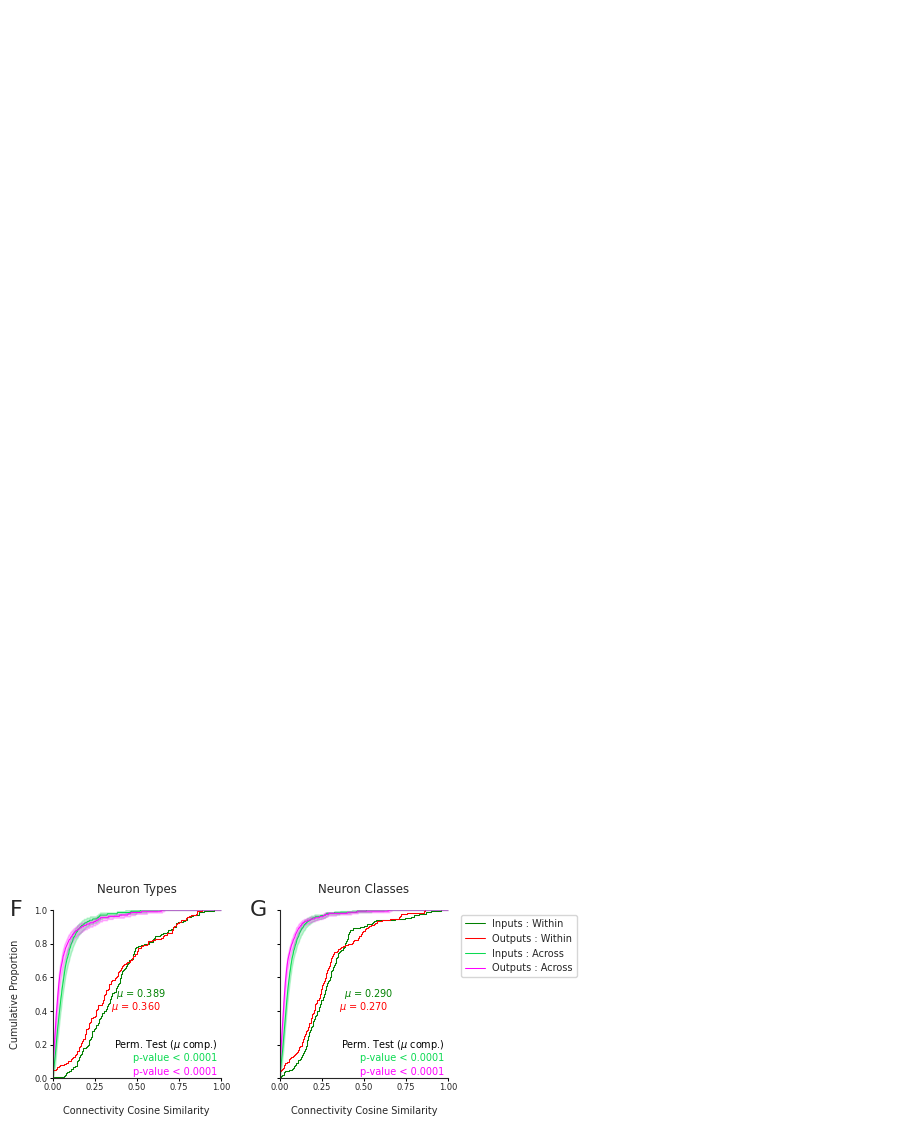

In [5]:
fig, ax = plt.subplots(figsize = (8.5, 11),
                       ncols = 4, nrows = 4,
                       sharey = True, sharex = True)

plt.subplots_adjust(hspace = 0.25, wspace = 0.35,
                    top = 1, bottom = 0, right = 1, left = 0)

# Position
xp = 0.98

#-----------------------------------------------------------------------------
# Helper -- mirrors plot_in_vs_out_ecdf in connectivity_variability.py
def draw_across_panel(a, across, level_label):
    """
    True within ECDFs (inputs and outputs) + resampled across-group bands,
    with permutation p-values and the within-group means annotated.
    """
    res_in_band  = across["across_input"]
    res_out_band = across["across_output"]

    # True within
    sns.ecdfplot(x = across["within_in_vals"],
                 color     = "green",
                 ax        = a,
                 linewidth = linewidth,
                 label     = "Inputs : Within")
    sns.ecdfplot(x = across["within_out_vals"],
                 color     = "red",
                 ax        = a,
                 linewidth = linewidth,
                 label     = "Outputs : Within")

    # Resampled across
    if res_in_band["median"] is not None:
        a.fill_between(x_grid, res_in_band["lo"], res_in_band["hi"],
                       color = "#0BDA51", alpha = fill_alpha)
        a.plot(x_grid, res_in_band["median"],
               color     = "#0BDA51",
               linewidth = linewidth,
               label     = "Inputs : Across")
    if res_out_band["median"] is not None:
        a.fill_between(x_grid, res_out_band["lo"], res_out_band["hi"],
                       color = "magenta", alpha = fill_alpha)
        a.plot(x_grid, res_out_band["median"],
               color     = "magenta",
               linewidth = linewidth,
               label     = "Outputs : Across")

    # Permutation stats
    n_runs = max(1, res_in_band["median"].size if res_in_band["median"] is not None else 1)
    a.text(xp, 0.20,
           r"Perm. Test ($\mu$ comp.)",
           va = "center", color = "black", ha = "right", fontsize = label_fontsize)
    if across["p_in"] <= 0:
        a.text(xp, 0.12, f"p-value < {1 / 10000:0.4f}",
               va = "center", color = "#0BDA51", ha = "right", fontsize = label_fontsize)
    else:
        a.text(xp, 0.12, f"p = {across['p_in']:0.4f}",
               va = "center", color = "#0BDA51", ha = "right", fontsize = label_fontsize)
    if across["p_out"] <= 0:
        a.text(xp, 0.04, f"p-value < {1 / 10000:0.4f}",
               va = "center", color = "magenta", ha = "right", fontsize = label_fontsize)
    else:
        a.text(xp, 0.04, f"p = {across['p_out']:0.4f}",
               va = "center", color = "magenta", ha = "right", fontsize = label_fontsize)

    # Mean placement
    a.text(0.38, 0.5,
           f"$\\mu$ = {across['within_in_mean']:.3f}",
           color = "green", va = "center", ha = "left", fontsize = label_fontsize)
    a.text(0.35, 0.425,
           f"$\\mu$ = {across['within_out_mean']:.3f}",
           color = "red", va = "center", ha = "left", fontsize = label_fontsize)


def style_axis(a, xlabel = "Connectivity Cosine Similarity"):
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    a.set_xlabel(xlabel, labelpad = 10, fontsize = label_fontsize)
    a.set_ylabel("")
    sns.despine(ax = a)
    a.set_aspect("equal")
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 2,
        width     = 0.75,
        pad       = 1.5)


#-----------------------------------------------------------------------------
# Within vs Across (cluster) Type Similarity -- inputs and outputs
draw_across_panel(ax[3, 0], across_cluster, "Clusters")
ax[3, 0].set_title("Neuron Types",   y = 1.05, fontsize = title_fontsize)

# Within vs Across Acronym (class) Similarity -- inputs and outputs
draw_across_panel(ax[3, 1], across_acronym, "Acronyms")
ax[3, 1].set_title("Neuron Classes", y = 1.05, fontsize = title_fontsize)


#-----------------------------------------------------------------------------
# Turn OFF All remaining axes
for a in ax[:3, :].flatten():
    a.axis("off")
for a in ax[3, 2:].flatten():
    a.axis("off")
#-----------------------------------------------------------------------------
# Styling
for a in [ax[3, 0], ax[3, 1]]:
    style_axis(a)

ax[3, 0].set_ylabel("Cumulative Proportion", labelpad = 10, fontsize = label_fontsize)

# Legend on the right of the across-panel row
ax[3, 1].legend(loc = "upper left", bbox_to_anchor = (1.05, 1.0), fontsize = label_fontsize)

# Panel Labels
place_panel_label(fig, ax[3, 0], "F", shx = -0.05, shy = shy,
                  label_kwargs = label_kwargs)
place_panel_label(fig, ax[3, 1], "G", shx = -0.035, shy = shy,
                  label_kwargs = label_kwargs)


# Save the Figure
plt.savefig("../Analysis_Outputs/Variability/Figure_04_Panels_In-vs-Out-Cluster-Acronym.pdf", bbox_inches = "tight", dpi = 1200)

## Supplementary Figure

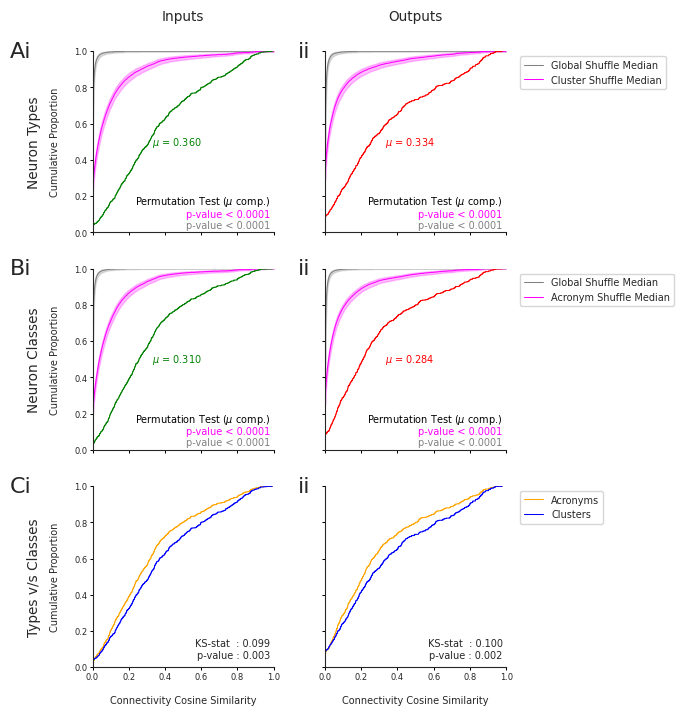

In [12]:
fig, ax = plt.subplots(figsize = (5.5, 8),
                       ncols = 2, nrows = 3,
                       sharey = True, sharex = True)

plt.subplots_adjust(hspace = 0.2, wspace = 0.2)

# Position
xp = 0.98

#-----------------------------------------------------------------------------
# Helpers
def draw_shuffle_panel(a, r, bands, side, true_color, shuffle_label):
    """
    True ECDF + global shuffle band + label shuffle band, with permutation
    p-values and the true mean annotated. Mirrors plot_shuffle_ecdf in the script.
    """
    keep = r["groups"]["Num_Neurons"].to_numpy() > 1
    true_vals = r["true"][side][keep]
    true_vals = true_vals[np.isfinite(true_vals)]

    gl  = bands[f"global_shuffle_{side}"]
    lab = bands[f"label_shuffle_{side}"]
    p_gl  = bands[f"p_global_{ 'in' if side == 'input' else 'out' }"]
    p_lab = bands[f"p_label_{  'in' if side == 'input' else 'out' }"]
    true_mean = bands["true_in_mean" if side == "input" else "true_out_mean"]

    # GLOBAL SHUFFLE
    a.fill_between(x_grid, gl["lo"], gl["hi"], color = "grey", alpha = fill_alpha)
    a.plot(x_grid, gl["median"],
           color     = "grey",
           linewidth = linewidth,
           label     = "Global Shuffle Median")

    # LABEL SHUFFLE
    a.fill_between(x_grid, lab["lo"], lab["hi"], color = "magenta", alpha = fill_alpha)
    a.plot(x_grid, lab["median"],
           color     = "magenta",
           linewidth = linewidth,
           label     = shuffle_label)

    # TRUE
    sns.ecdfplot(x = true_vals, ax = a, color = true_color, linewidth = linewidth)

    # Permutation stats
    n_runs = r["global_shuffle"][side].shape[0]
    a.text(xp, 0.17,
           r"Permutation Test ($\mu$ comp.)",
           va = "center", color = "black", ha = "right", fontsize = label_fontsize)
    if p_lab <= 0:
        a.text(xp, 0.10, f"p-value < {1 / n_runs:0.4f}",
               va = "center", color = "magenta", ha = "right", fontsize = label_fontsize)
    else:
        a.text(xp, 0.10, f"p = {p_lab:0.4f}",
               va = "center", color = "magenta", ha = "right", fontsize = label_fontsize)
    if p_gl <= 0:
        a.text(xp, 0.04, f"p-value < {1 / n_runs:0.4f}",
               va = "center", color = "grey", ha = "right", fontsize = label_fontsize)
    else:
        a.text(xp, 0.04, f"p = {p_gl:0.4f}",
               va = "center", color = "grey", ha = "right", fontsize = label_fontsize)

    # Mean placement
    a.text(0.33, 0.5,
           f"$\\mu$ = {true_mean:.3f}",
           color = true_color, va = "center", ha = "left", fontsize = label_fontsize)


def style_axis(a, xlabel = "Connectivity Cosine Similarity"):
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    a.set_xlabel(xlabel, labelpad = 10, fontsize = label_fontsize)
    a.set_ylabel("")
    sns.despine(ax = a)
    a.set_aspect("equal")
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 2,
        width     = 0.75,
        pad       = 1.5)


#-----------------------------------------------------------------------------
# Row 0 -- Cluster shuffle ECDFs
draw_shuffle_panel(ax[0, 0], r_cluster, bands_cluster, "input",
                   true_color = "green", shuffle_label = "Cluster Shuffle Median")
draw_shuffle_panel(ax[0, 1], r_cluster, bands_cluster, "output",
                   true_color = "red",   shuffle_label = "Cluster Shuffle Median")

# Row 1 -- Acronym shuffle ECDFs
draw_shuffle_panel(ax[1, 0], r_acronym, bands_acronym, "input",
                   true_color = "green", shuffle_label = "Acronym Shuffle Median")
draw_shuffle_panel(ax[1, 1], r_acronym, bands_acronym, "output",
                   true_color = "red",   shuffle_label = "Acronym Shuffle Median")

#-----------------------------------------------------------------------------
# Row 2 -- Cluster vs Acronym true ECDFs (input | output) with KS
keep_c = r_cluster["groups"]["Num_Neurons"].to_numpy() > 1
keep_a = r_acronym["groups"]["Num_Neurons"].to_numpy() > 1

for col, side in enumerate(["input", "output"]):
    cl = r_cluster["true"][side][keep_c]
    ac = r_acronym["true"][side][keep_a]
    cl = cl[np.isfinite(cl)]
    ac = ac[np.isfinite(ac)]

    sns.ecdfplot(x = ac, ax = ax[2, col],
                 color = "orange", linewidth = linewidth, label = "Acronyms")
    sns.ecdfplot(x = cl, ax = ax[2, col],
                 color = "blue",   linewidth = linewidth, label = "Clusters")

    stat, p_value = ks_2samp(ac, cl)
    ax[2, col].text(xp, 0.1,
                    f"KS-stat  : {stat:0.3f}\np-value : {p_value:0.3f}",
                    va = "center", ha = "right", fontsize = label_fontsize)

#-----------------------------------------------------------------------------
# Styling
for a in ax.flatten():
    style_axis(a)

for r in range(3):
    ax[r, 0].set_ylabel("Cumulative Proportion", labelpad = 10, fontsize = label_fontsize)

# Titles
ax[0, 0].set_title("Inputs",  y = 1.125, fontsize = title_fontsize * 1.15)
ax[0, 1].set_title("Outputs", y = 1.125, fontsize = title_fontsize * 1.15)

# Association Labels
ax[0, 0].text(-0.325, 0.5,
              s  = "Neuron Types",
              ha = "center",
              va = "center",
              rotation = 90,
              fontsize = title_fontsize * 1.15)
            
# Association Labels
ax[1, 0].text(-0.325, 0.5,
              s  = "Neuron Classes",
              ha = "center",
              va = "center",
              rotation = 90,
              fontsize = title_fontsize * 1.15)

# Association Labels
ax[2, 0].text(-0.325, 0.5,
              s  = "Types v/s Classes",
              ha = "center",
              va = "center",
              rotation = 90,
              fontsize = title_fontsize * 1.15)


# Legends -- put on the right of each row
ax[0, 1].legend(loc = "upper left", bbox_to_anchor = (1.05, 1.0), fontsize = label_fontsize)
ax[1, 1].legend(loc = "upper left", bbox_to_anchor = (1.05, 1.0), fontsize = label_fontsize)
ax[2, 1].legend(loc = "upper left", bbox_to_anchor = (1.05, 1.0), fontsize = label_fontsize)

# Panel Labels
place_panel_label(fig, ax[0, 0], "Ai", shx = shx1, shy = shy,
                  label_kwargs = label_kwargs)
place_panel_label(fig, ax[0, 1], "ii", shx = shx2, shy = shy,
                  label_kwargs = label_kwargs)
place_panel_label(fig, ax[1, 0], "Bi", shx = shx1, shy = shy,
                  label_kwargs = label_kwargs)
place_panel_label(fig, ax[1, 1], "ii", shx = shx2, shy = shy,
                  label_kwargs = label_kwargs)
place_panel_label(fig, ax[2, 0], "Ci", shx = shx1, shy = shy,
                  label_kwargs = label_kwargs)
place_panel_label(fig, ax[2, 1], "ii", shx = shx2, shy = shy,
                  label_kwargs = label_kwargs)

# Save the Figure
plt.savefig("../Analysis_Outputs/Variability/Figure_04_Supplementary_Connectivity-Variability-Shuffling.pdf", bbox_inches = "tight", dpi = 1200)

# <center>**हो गया दोस्तों!**</center>